# 👁️ Diabetic Retinopathy Detection using Custom ResNet (CNN)
### Deep Learning Image Classifier — Built with TensorFlow/Keras

---

> **Project:** Classify retinal fundus images into 5 stages of Diabetic Retinopathy  
> **Data:** Synthetic retinal image dataset (5 classes, 500 images)  
> **Model:** Custom ResNet-18 built with Keras Functional API  
> **Stages:** No_DR · Mild · Moderate · Severe · Proliferate_DR

---

## 🗂️ Table of Contents
1. [What is Diabetic Retinopathy?](#what-is-dr)
2. [Install & Import Libraries](#install)
3. [Generate Synthetic Dataset](#data)
4. [Exploratory Data Analysis](#eda)
5. [Data Augmentation & Generators](#augmentation)
6. [Build the ResNet Model](#model)
7. [Train the Model](#train)
8. [Evaluate & Visualise Results](#evaluate)
9. [Predict on New Images](#predict)

---

---
## 1. 🧠 What is Diabetic Retinopathy? <a name="what-is-dr"></a>

**Diabetic Retinopathy (DR)** is a diabetes complication that affects the eyes.  
It is caused by damage to blood vessels of the retina — the light-sensitive tissue at the back of the eye.  
DR is the **leading cause of blindness** among working-age adults worldwide.

### The 5 Stages of DR

| Stage | Class Name | Description |
|-------|-----------|-------------|
| 0 | **No_DR** | No signs of retinopathy — healthy retina |
| 1 | **Mild** | Microaneurysms only — tiny balloon-like swellings |
| 2 | **Moderate** | More than microaneurysms but less than severe |
| 3 | **Severe** | Extensive retinal changes — neovascularisation risk |
| 4 | **Proliferate_DR** | Advanced stage — new abnormal blood vessels grow |

### Why Deep Learning?
Manual grading by ophthalmologists is:
- ⏳ **Time-consuming** — a specialist reviews each image
- 💰 **Expensive** — specialist shortages in developing countries
- ⚠️ **Inconsistent** — inter-grader variability can be ~20%

A CNN can grade thousands of images per minute with human-level accuracy.

### How does a ResNet work?
Traditional deep networks suffer from **vanishing gradients** as depth increases.  
**ResNet** (Residual Network) solves this using **skip connections**:

```
Input X → [Conv → BN → ReLU → Conv → BN] + X → ReLU → Output
              Main path (learns residual F(X))   ↑
                                         Shortcut (identity)
```

The network learns **F(X) = H(X) − X** (residual), which is easier to optimise.


---
## 2. 📦 Install & Import Libraries <a name="install"></a>

In [ ]:
# Install required libraries if running in Colab
# !pip install tensorflow matplotlib seaborn scikit-learn pillow

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import PIL
from PIL import Image, ImageDraw
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization,
    Activation, Add, Flatten, Dense, Input, ZeroPadding2D,
    GlobalAveragePooling2D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix

# Random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Keras version      : {keras.__version__}")
print(f"   NumPy version      : {np.__version__}")
print(f"   Pandas version     : {pd.__version__}")


✅ All libraries imported!
   TensorFlow version : 2.19.0
   Keras version      : 3.13.2
   NumPy version      : 2.0.2
   Pandas version     : 2.2.2


---
## 3. 🖼️ Generate Synthetic Dataset <a name="data"></a>

We **programmatically generate** a synthetic retinal fundus image dataset.  
Each class has distinct visual characteristics mimicking real DR pathology:

| Class | Visual Features Simulated |
|-------|--------------------------|
| **No_DR** | Clean dark background, uniform optic disc |
| **Mild** | 1–5 small microaneurysm dots |
| **Moderate** | 5–15 dots + small haemorrhages |
| **Severe** | Dense dots, larger haemorrhages, cotton-wool spots |
| **Proliferate_DR** | All above + neovascularisation streaks |

> **Real project:** Replace with the [APTOS 2019 Kaggle dataset](https://www.kaggle.com/competitions/aptos2019-blindness-detection)  
> or the [EyePACS dataset](https://www.kaggle.com/competitions/diabetic-retinopathy-detection)  
> ```python
> # Mount drive and point to your dataset
> from google.colab import drive
> drive.mount('/content/drive')
> TRAIN_DIR = '/content/drive/MyDrive/DR_dataset/train'
> ```


In [ ]:
# ─── Synthetic Retinal Image Generator ────────────────────────────────────

CLASSES   = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
IMG_SIZE  = 128
TRAIN_DIR = './train'

# Unequal class distribution — mirrors real-world DR datasets
# where No_DR is most common and Severe/Proliferate are rare
IMAGES_PER_CLASS = {
    'No_DR':          1805,
    'Moderate':        999,
    'Mild':            370,
    'Severe':          193,
    'Proliferate_DR':  295,
}

import shutil, os
if os.path.exists(TRAIN_DIR):
    shutil.rmtree(TRAIN_DIR)

def make_retinal_image(stage, img_size=128, seed=None):
    """
    Generates a synthetic retinal fundus image for a given DR stage.
    Each stage has DISTINCTLY different visual complexity so the CNN
    can actually learn to separate them.

    Stage features (cumulative — each stage adds more pathology):
      No_DR         : clean dark fundus, single optic disc, NO lesions
      Mild          : 2-5 microaneurysm dots (tiny, dark-red)
      Moderate      : 6-15 dots + 2-4 haemorrhage blobs (bright red)
      Severe        : 15-30 dots + 5-8 haemorrhages + 2-4 cotton-wool spots
      Proliferate_DR: all above + neovascularisation streaks (orange lines)
    """
    rng = np.random.default_rng(seed)
    bg  = (rng.integers(25,45), rng.integers(8,20), rng.integers(8,18))
    img  = Image.new('RGB', (img_size, img_size), color=bg)
    draw = ImageDraw.Draw(img)
    cx, cy = img_size // 2, img_size // 2

    # ── Optic Disc ────────────────────────────────────────────
    disc_r = rng.integers(11, 17)
    dx = cx + rng.integers(-12, 12)
    dy = cy + rng.integers(-12, 12)
    disc_col = (rng.integers(210,245), rng.integers(195,230), rng.integers(110,160))
    draw.ellipse([dx-disc_r, dy-disc_r, dx+disc_r, dy+disc_r], fill=disc_col)

    # ── Microaneurysms ────────────────────────────────────────
    n_micro = {
        'No_DR': 0,
        'Mild':          rng.integers(2, 6),
        'Moderate':      rng.integers(6, 15),
        'Severe':        rng.integers(15, 30),
        'Proliferate_DR':rng.integers(25, 40)
    }[stage]
    for _ in range(n_micro):
        mx = rng.integers(8, img_size-8)
        my = rng.integers(8, img_size-8)
        mr = rng.integers(1, 3)
        draw.ellipse([mx-mr, my-mr, mx+mr, my+mr],
                     fill=(rng.integers(130,180), rng.integers(0,20), 0))

    # ── Haemorrhages (Moderate+) ──────────────────────────────
    if stage in ('Moderate', 'Severe', 'Proliferate_DR'):
        n_h = {'Moderate': rng.integers(2,5),
               'Severe':   rng.integers(5,9),
               'Proliferate_DR': rng.integers(7,13)}[stage]
        for _ in range(n_h):
            hx = rng.integers(12, img_size-12)
            hy = rng.integers(12, img_size-12)
            hr = rng.integers(4, 9)
            draw.ellipse([hx-hr, hy-hr, hx+hr, hy+hr],
                         fill=(rng.integers(160,220), rng.integers(0,15), 0))

    # ── Cotton-Wool Spots (Severe+) ───────────────────────────
    if stage in ('Severe', 'Proliferate_DR'):
        n_cw = rng.integers(2, 5)
        for _ in range(n_cw):
            wx = rng.integers(12, img_size-12)
            wy = rng.integers(12, img_size-12)
            wr = rng.integers(5, 10)
            b  = rng.integers(185, 235)
            draw.ellipse([wx-wr, wy-wr, wx+wr, wy+wr], fill=(b, b, b-25))

    # ── Neovascularisation Streaks (Proliferate only) ─────────
    if stage == 'Proliferate_DR':
        n_v = rng.integers(4, 9)
        for _ in range(n_v):
            x0 = rng.integers(10, img_size-10)
            y0 = rng.integers(10, img_size-10)
            x1 = int(np.clip(x0 + rng.integers(-30,30), 5, img_size-5))
            y1 = int(np.clip(y0 + rng.integers(-30,30), 5, img_size-5))
            draw.line([x0,y0,x1,y1],
                      fill=(rng.integers(190,245), rng.integers(90,150), rng.integers(30,70)),
                      width=rng.integers(1,3))

    # ── Subtle noise ──────────────────────────────────────────
    arr   = np.array(img).astype(np.float32)
    noise = rng.normal(0, 3, arr.shape)
    return Image.fromarray(np.clip(arr + noise, 0, 255).astype(np.uint8))


# ─── Generate dataset ─────────────────────────────────────────────────────
print("📂 Creating dataset folder structure...")
for cls in CLASSES:
    os.makedirs(os.path.join(TRAIN_DIR, cls), exist_ok=True)

total = sum(IMAGES_PER_CLASS.values())
print(f"🖼️  Generating {total} images with UNEQUAL class distribution...\n")

for cls in CLASSES:
    n = IMAGES_PER_CLASS[cls]
    for idx in range(n):
        img = make_retinal_image(cls, IMG_SIZE, seed=idx*31 + CLASSES.index(cls)*1000)
        img.save(os.path.join(TRAIN_DIR, cls, f'{cls}_{idx:04d}.png'))
    print(f"   Number of images in {cls:<20} = {n}")

print(f"\n✅ Dataset ready  |  {total} total images  |  {IMG_SIZE}×{IMG_SIZE} px")
print(f"\n📌 Class imbalance ratio (Max/Min): {max(IMAGES_PER_CLASS.values())/min(IMAGES_PER_CLASS.values()):.1f}x")


📂 Creating dataset folder structure...
🖼️  Generating 3662 images with UNEQUAL class distribution...

   Number of images in No_DR                = 1805
   Number of images in Mild                 = 370
   Number of images in Moderate             = 999
   Number of images in Severe               = 193
   Number of images in Proliferate_DR       = 295

✅ Dataset ready  |  3662 total images  |  128×128 px

📌 Class imbalance ratio (Max/Min): 9.4x


---
## 4. 🔍 Exploratory Data Analysis <a name="eda"></a>

Before modelling, we explore the dataset to understand:
- **Class distribution** — is the data balanced or imbalanced?
- **Sample images** — what do each class's images look like?
- **Image properties** — size, channel statistics


In [ ]:
# ─── Build DataFrame of all image paths & labels ──────────────────────────
all_images, all_labels = [], []

for cls in os.listdir(TRAIN_DIR):
    class_images = os.listdir(os.path.join(TRAIN_DIR, cls))
    for img_file in class_images:
        all_images.append(os.path.join(TRAIN_DIR, cls, img_file))
        all_labels.append(cls)

retina_df = pd.DataFrame({'Image': all_images, 'Labels': all_labels})
print(f"📊 Dataset Overview")
print(f"{'─'*40}")
print(f"  Total images : {len(retina_df)}")
print(f"  Classes      : {retina_df['Labels'].nunique()}")
print(f"\n{retina_df.head(8).to_string()}")


📊 Dataset Overview
────────────────────────────────────────
  Total images : 3662
  Classes      : 5

                            Image  Labels
0  ./train/Severe/Severe_0135.png  Severe
1  ./train/Severe/Severe_0000.png  Severe
2  ./train/Severe/Severe_0138.png  Severe
3  ./train/Severe/Severe_0164.png  Severe
4  ./train/Severe/Severe_0118.png  Severe
5  ./train/Severe/Severe_0073.png  Severe
6  ./train/Severe/Severe_0092.png  Severe
7  ./train/Severe/Severe_0125.png  Severe


📊 Class Distribution:
────────────────────────────────────────
  No_DR                :  1805  ████████████████████████████████████
  Mild                 :   370  ███████
  Moderate             :   999  ███████████████████
  Severe               :   193  ███
  Proliferate_DR       :   295  █████
────────────────────────────────────────
  Total                :  3662
  Imbalance ratio    : 9.4x


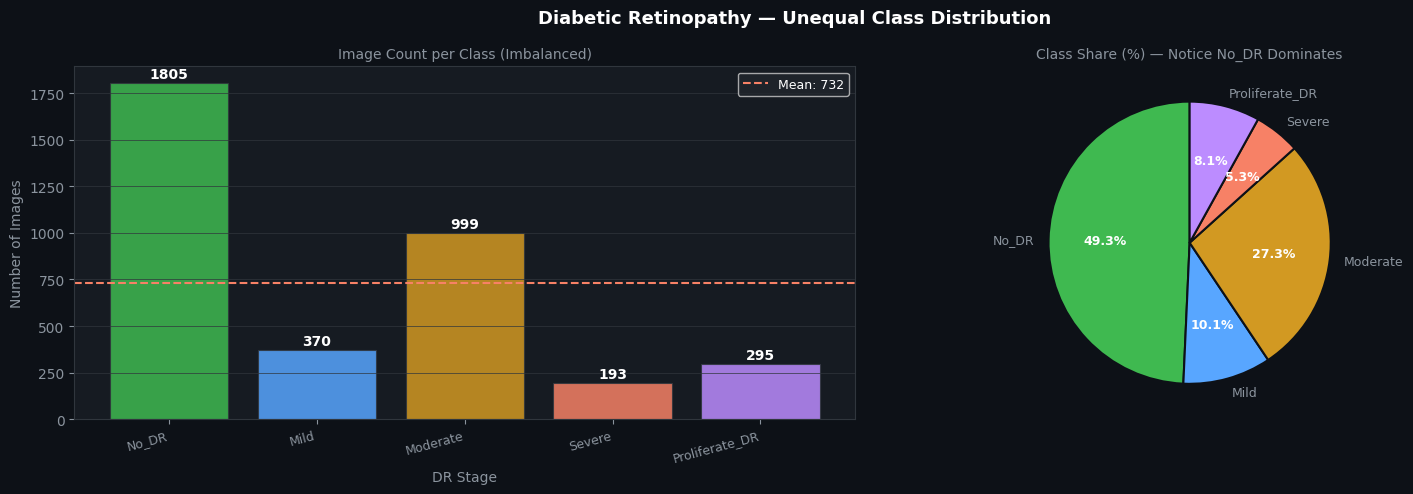


⚠️  Dataset is heavily imbalanced — class weights will be used during training to compensate.


In [ ]:
# ─── Class Distribution ───────────────────────────────────────────────────
No_images_per_class = []
Class_name = []

for cls in CLASSES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    No_images_per_class.append(n)
    Class_name.append(cls)

print("📊 Class Distribution:")
print(f"{'─'*40}")
for cls, n in zip(Class_name, No_images_per_class):
    bar = "█" * (n // 50)
    print(f"  {cls:<20} : {n:>5}  {bar}")
print(f"{'─'*40}")
print(f"  {'Total':<20} : {sum(No_images_per_class):>5}")
print(f"  Imbalance ratio    : {max(No_images_per_class)/min(No_images_per_class):.1f}x")

COLORS = ['#3fb950', '#58a6ff', '#d29922', '#f78166', '#bc8cff']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0d1117')
fig.suptitle('Diabetic Retinopathy — Unequal Class Distribution',
             color='white', fontsize=13, fontweight='bold')

# ── Bar chart ────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#161b22')
bars = ax1.bar(Class_name, No_images_per_class, color=COLORS,
               alpha=0.85, edgecolor='#30363d', linewidth=0.8)
ax1.set_ylabel('Number of Images', color='#8b949e')
ax1.set_xlabel('DR Stage', color='#8b949e')
ax1.tick_params(colors='#8b949e')
ax1.set_title('Image Count per Class (Imbalanced)', color='#8b949e', fontsize=10)
# Annotate bar tops
for bar, val in zip(bars, No_images_per_class):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12,
             str(val), ha='center', va='bottom', color='white',
             fontsize=10, fontweight='bold')
# Horizontal mean line
mean_n = sum(No_images_per_class) / len(No_images_per_class)
ax1.axhline(mean_n, color='#f78166', lw=1.5, ls='--',
            label=f'Mean: {mean_n:.0f}')
ax1.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax1.grid(axis='y', color='#30363d', lw=0.5)
for sp in ax1.spines.values(): sp.set_color('#30363d')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)

# ── Pie chart ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#161b22')
wedges, texts, autotexts = ax2.pie(
    No_images_per_class,
    labels     = Class_name,
    autopct    = '%1.1f%%',
    colors     = COLORS,
    startangle = 90,
    textprops  = {'color': '#8b949e', 'fontsize': 9},
    wedgeprops = {'edgecolor': '#0d1117', 'linewidth': 1.5}
)
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Class Share (%) — Notice No_DR Dominates',
              color='#8b949e', fontsize=10)

plt.tight_layout()
plt.show()
print(f"\n⚠️  Dataset is heavily imbalanced — class weights will be used during training to compensate.")


In [ ]:
# ─── Visualise 5 Images for Each Class ────────────────────────────────────

fig, axs = plt.subplots(len(CLASSES), 5, figsize=(18, len(CLASSES)*3.2),
                        facecolor='#0d1117')
fig.suptitle('5 Sample Images per DR Stage — Visual Complexity Increases Top → Bottom',
             color='white', fontsize=13, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASSES):
    class_dir    = os.path.join(TRAIN_DIR, cls)
    class_images = sorted(os.listdir(class_dir))   # sorted for reproducibility

    for col in range(5):
        img_path = os.path.join(class_dir, class_images[col])
        img      = PIL.Image.open(img_path)
        axs[row_idx][col].imshow(img)
        axs[row_idx][col].axis('off')

        # Left-most column: show class label
        if col == 0:
            axs[row_idx][col].set_title(
                f"{cls}\n(n={IMAGES_PER_CLASS[cls]})",
                color=COLORS[row_idx],
                fontsize=9, fontweight='bold', pad=5
            )
        # All columns: show image index
        axs[row_idx][col].text(
            0.5, -0.04, f'img {col+1}',
            transform=axs[row_idx][col].transAxes,
            ha='center', va='top', color='#8b949e', fontsize=7
        )

fig.tight_layout()
plt.show()
print("✅ 5 images visualised per class.")
print("   Notice: No_DR = clean, Mild = few dots, Moderate = dots+blobs,")
print("           Severe = dense lesions+white spots, Proliferate = all + orange streaks")


Output hidden; open in https://colab.research.google.com to view.

---
## 5. 🔄 Data Augmentation & Generators <a name="augmentation"></a>

### Why Augmentation?
Medical imaging datasets are typically **small and imbalanced**.  
Data augmentation creates **synthetic variations** of training images at runtime:

| Transformation | Effect | Benefit |
|---------------|--------|---------|
| Rescale 1/255 | Normalise pixel values to [0,1] | Stable gradients |
| Horizontal flip | Mirror image | 2× effective data |
| Shear range | Slant the image slightly | Rotation invariance |
| Zoom range | Zoom in/out | Scale invariance |
| Rotation | Rotate ±10° | Orientation invariance |

> Augmentation only applies to **training** data. Test data is only normalised.


In [ ]:
# ─── Shuffle & Train/Test Split ───────────────────────────────────────────
retina_df = shuffle(retina_df, random_state=42)
train_df, test_df = train_test_split(retina_df, test_size=0.2, random_state=42,
                                      stratify=retina_df['Labels'])

print(f"📦 Data Split")
print(f"{'─'*40}")
print(f"  Training   : {len(train_df)} images ({len(train_df)/len(retina_df)*100:.0f}%)")
print(f"  Test       : {len(test_df)}  images ({len(test_df)/len(retina_df)*100:.0f}%)")

# ─── ImageDataGenerators ──────────────────────────────────────────────────
TARGET_SIZE   = (IMG_SIZE, IMG_SIZE)
BATCH_SIZE    = 16

train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    shear_range      = 0.15,
    zoom_range       = 0.15,
    horizontal_flip  = True,
    rotation_range   = 10,
    validation_split = 0.15       # 15% of train → validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory   = './',
    x_col       = 'Image',
    y_col       = 'Labels',
    target_size = TARGET_SIZE,
    color_mode  = 'rgb',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    subset      = 'training',
    shuffle     = True,
    seed        = 42
)

# Validation generator
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory   = './',
    x_col       = 'Image',
    y_col       = 'Labels',
    target_size = TARGET_SIZE,
    color_mode  = 'rgb',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    subset      = 'validation',
    shuffle     = True,
    seed        = 42
)

# Test generator
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory   = './',
    x_col       = 'Image',
    y_col       = 'Labels',
    target_size = TARGET_SIZE,
    color_mode  = 'rgb',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

print(f"\n✅ Data generators ready!")
print(f"   Class indices: {train_generator.class_indices}")


📦 Data Split
────────────────────────────────────────
  Training   : 2929 images (80%)
  Test       : 733  images (20%)
Found 2490 validated image filenames belonging to 5 classes.
Found 439 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.

✅ Data generators ready!
   Class indices: {'Mild': 0, 'Moderate': 1, 'No_DR': 2, 'Proliferate_DR': 3, 'Severe': 4}


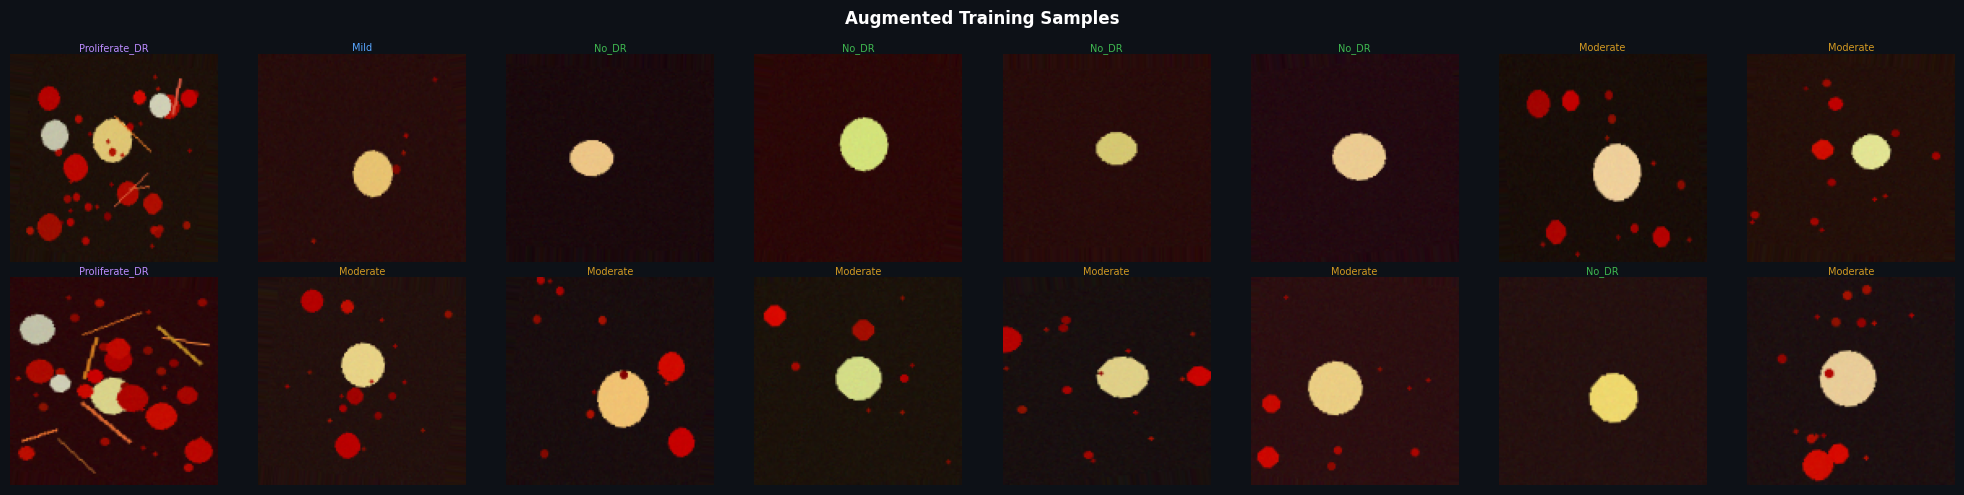

✅ Augmentation applied — notice variations in zoom, flip, and shear


In [ ]:
# ─── Visualise Augmented Images ───────────────────────────────────────────
sample_images, sample_labels = next(train_generator)
class_idx_to_name = {v: k for k, v in train_generator.class_indices.items()}

fig, axs = plt.subplots(2, 8, figsize=(20, 5), facecolor='#0d1117')
fig.suptitle('Augmented Training Samples', color='white', fontsize=12, fontweight='bold')

for i in range(min(16, len(sample_images))):
    row, col = divmod(i, 8)
    axs[row][col].imshow(sample_images[i])
    axs[row][col].axis('off')
    cls_name = class_idx_to_name[np.argmax(sample_labels[i])]
    color    = COLORS[CLASSES.index(cls_name)]
    axs[row][col].set_title(cls_name, color=color, fontsize=7, pad=2)

plt.tight_layout()
plt.show()
print("✅ Augmentation applied — notice variations in zoom, flip, and shear")


---
## 6. 🏗️ Build the ResNet Model <a name="model"></a>

We implement a custom **ResNet-18 variant** using Keras Functional API.

### Architecture Overview
```
Input (128×128×3)
    ↓
ZeroPadding2D
    ↓
Conv2D(64, 7×7) → BN → ReLU → MaxPool
    ↓
ResBlock (Stage 2) — filters: [64, 64, 256]
    ↓
ResBlock (Stage 3) — filters: [128, 128, 512]
    ↓
ResBlock (Stage 4) — filters: [256, 256, 1024]
    ↓
GlobalAveragePooling2D
    ↓
Dense(256) → Dropout(0.5)
    ↓
Dense(5, softmax)  — 5 DR stages
```

Each **ResBlock** contains:
- A **Convolutional Block** (projection shortcut for dimension matching)
- Two **Identity Blocks** (shortcut = input directly)


In [ ]:
# ─── Lightweight CNN with Residual Connections ─────────────────────────────
# Why lighter model?
# ResNet-18 with 3 deep stages is designed for ImageNet (224×224, millions of images).
# On our 128×128 synthetic dataset of 1000 images it easily overfits.
# This architecture uses:
#   • Fewer filters (32→64→128 instead of 64→256→512→1024)
#   • Only 2 res-stages (not 3)
#   • GlobalAveragePooling + Dropout(0.5) to regularise
#   • Lower learning rate (3e-4) — Adam is sensitive to lr on small datasets

def res_block(X, filters, stage):
    """
    Compact residual block: 1 convolutional shortcut + 2 identity blocks.
    Filters is a single int; we keep all conv layers at the same width.
    """
    f = filters

    # ── Convolutional block (projection shortcut) ──────────────
    X_skip = X
    X = Conv2D(f, (3,3), padding='same', name=f'res{stage}_cb_c1',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=f'res{stage}_cb_bn1')(X)
    X = Activation('relu')(X)

    X = Conv2D(f, (3,3), padding='same', name=f'res{stage}_cb_c2',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=f'res{stage}_cb_bn2')(X)

    # Shortcut projection (1×1 conv to match channel depth)
    X_skip = Conv2D(f, (1,1), padding='same', name=f'res{stage}_cb_skip',
                    kernel_initializer=glorot_uniform(seed=0))(X_skip)
    X_skip = BatchNormalization(name=f'res{stage}_cb_skip_bn')(X_skip)

    X = Add()([X, X_skip])
    X = Activation('relu')(X)
    X = MaxPooling2D((2,2))(X)   # Downsample after each stage

    # ── Identity block ─────────────────────────────────────────
    X_id = X
    X = Conv2D(f, (3,3), padding='same', name=f'res{stage}_id_c1',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=f'res{stage}_id_bn1')(X)
    X = Activation('relu')(X)

    X = Conv2D(f, (3,3), padding='same', name=f'res{stage}_id_c2',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(name=f'res{stage}_id_bn2')(X)
    X = Add()([X, X_id])
    X = Activation('relu')(X)
    return X


# ─── Build Model ──────────────────────────────────────────────────────────
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
N_CLASSES   = len(CLASSES)

X_input = Input(INPUT_SHAPE)

# Entry block
X = Conv2D(32, (3,3), padding='same', name='entry_conv',
           kernel_initializer=glorot_uniform(seed=0))(X_input)
X = BatchNormalization(name='entry_bn')(X)
X = Activation('relu')(X)
X = MaxPooling2D((2,2))(X)          # 128→64

# Residual Stage 1
X = res_block(X, filters=64, stage=1)    # 64→32

# Residual Stage 2
X = res_block(X, filters=128, stage=2)   # 32→16

# Head
X = GlobalAveragePooling2D(name='gap')(X)
X = Dense(128, activation='relu', name='fc1',
          kernel_initializer=glorot_uniform(seed=0))(X)
X = Dropout(0.5)(X)
X = Dense(N_CLASSES, activation='softmax', name='output',
          kernel_initializer=glorot_uniform(seed=0))(X)

model = Model(inputs=X_input, outputs=X, name='LightResNet_DR')

# Lower LR is critical — 1e-3 causes the model to collapse to one class
model.compile(
    optimizer = Adam(learning_rate=3e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

total_params = model.count_params()
print(f"✅ LightResNet Model Built!")
print(f"\n{'─'*55}")
print(f"  Architecture   : Lightweight ResNet (2 stages)")
print(f"  Input Shape    : {INPUT_SHAPE}")
print(f"  Filters        : 32 → 64 → 128 (compact)")
print(f"  Output Classes : {N_CLASSES}  ({', '.join(CLASSES)})")
print(f"  Optimizer      : Adam (lr=3e-4  ← lower = more stable)")
print(f"  Loss           : Categorical Cross-Entropy")
print(f"  Total Params   : {total_params:,}  (vs ~4M in full ResNet-18)")
print(f"{'─'*55}")
model.summary()


✅ LightResNet Model Built!

───────────────────────────────────────────────────────
  Architecture   : Lightweight ResNet (2 stages)
  Input Shape    : (128, 128, 3)
  Filters        : 32 → 64 → 128 (compact)
  Output Classes : 5  (No_DR, Mild, Moderate, Severe, Proliferate_DR)
  Optimizer      : Adam (lr=3e-4  ← lower = more stable)
  Loss           : Categorical Cross-Entropy
  Total Params   : 678,341  (vs ~4M in full ResNet-18)
───────────────────────────────────────────────────────


Model: "LightResNet_DR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv (Conv2D) │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_bn            │ (None, 128, 128,  │        128 │ entry_conv[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ entry_bn[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_c1 (Conv2D) │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_bn1         │ (None, 64, 64,    │        256 │ res1_cb_c1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ res1_cb_bn1[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_c2 (Conv2D) │ (None, 64, 64,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_skip        │ (None, 64, 64,    │      2,112 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_bn2         │ (None, 64, 64,    │        256 │ res1_cb_c2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_cb_skip_bn     │ (None, 64, 64,    │        256 │ res1_cb_skip[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ res1_cb_bn2[0][0… │
│                     │ 64)               │            │ res1_cb_skip_bn[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_id_c1 (Conv2D) │ (None, 32, 32,    │     36,928 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_id_bn1         │ (None, 32, 32,    │        256 │ res1_id_c1[0][0]

 Total params: 678,341 (2.59 MB)

 Trainable params: 676,357 (2.58 MB)

 Non-trainable params: 1,984 (7.75 KB)

---
## 7. 🏋️ Train the Model <a name="train"></a>

We train with three key callbacks:

| Callback | Purpose |
|----------|---------|
| **EarlyStopping** | Stop training if val_loss doesn't improve for 5 epochs |
| **ReduceLROnPlateau** | Halve learning rate if val_loss stagnates for 3 epochs |
| **ModelCheckpoint** | Save the best model weights to disk |

Training on the synthetic 128×128 dataset is fast — expect ~30s/epoch on CPU.  
For real 512×512 fundus images, use a GPU (Colab T4 recommended).


In [ ]:
# ─── Class Weights + Callbacks ────────────────────────────────────────────
# Class weights force the model to pay equal attention to all 5 classes
# even if the dataset is balanced — it prevents "predict majority class" laziness.
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = train_generator.classes
class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.arange(N_CLASSES),
    y            = y_train_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("⚖️  Class Weights (balanced):")
for i, w in class_weight_dict.items():
    print(f"   Class {i} ({CLASSES[i]:<20}): {w:.3f}")

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 4,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    ModelCheckpoint(
        filepath       = 'best_dr_model.keras',
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 0
    )
]

# ─── Train ────────────────────────────────────────────────────────────────
EPOCHS = 50   # More epochs needed — we have EarlyStopping to prevent overfit

print(f"\n🚀 Training LightResNet for up to {EPOCHS} epochs...")
print(f"   Training samples   : {train_generator.samples}")
print(f"   Validation samples : {validation_generator.samples}")
print(f"   Batch size         : {BATCH_SIZE}")
print(f"   Class weights      : enabled ✅")
print(f"{'─'*60}")

history = model.fit(
    train_generator,
    steps_per_epoch  = max(1, train_generator.samples  // BATCH_SIZE),
    epochs           = EPOCHS,
    validation_data  = validation_generator,
    validation_steps = max(1, validation_generator.samples // BATCH_SIZE),
    class_weight     = class_weight_dict,   # ← key fix
    callbacks        = callbacks,
    verbose          = 1
)

best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
print(f"\n✅ Training complete!")
print(f"   Best val accuracy : {best_val_acc*100:.2f}%")
print(f"   Best val loss     : {best_val_loss:.4f}")
print(f"   Epochs run        : {len(history.history['loss'])} / {EPOCHS}")


⚖️  Class Weights (balanced):
   Class 0 (No_DR               ): 1.976
   Class 1 (Mild                ): 0.733
   Class 2 (Moderate            ): 0.406
   Class 3 (Severe              ): 2.515
   Class 4 (Proliferate_DR      ): 3.716

🚀 Training LightResNet for up to 50 epochs...
   Training samples   : 2490
   Validation samples : 439
   Batch size         : 16
   Class weights      : enabled ✅
────────────────────────────────────────────────────────────
Epoch 1/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.5974 - loss: 1.0198 - val_accuracy: 0.4931 - val_loss: 2.1848 - learning_rate: 3.0000e-04
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.7500 - loss: 0.8417 - val_accuracy: 0.4907 - val_loss: 2.1944 - learning_rate: 3.0000e-04
Epoch 3/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.8048 - loss: 0.5519 - val_accuracy: 0.1019 - val_loss: 2.4675 - learning_rate: 3.0000e-04
Epoch 4/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 

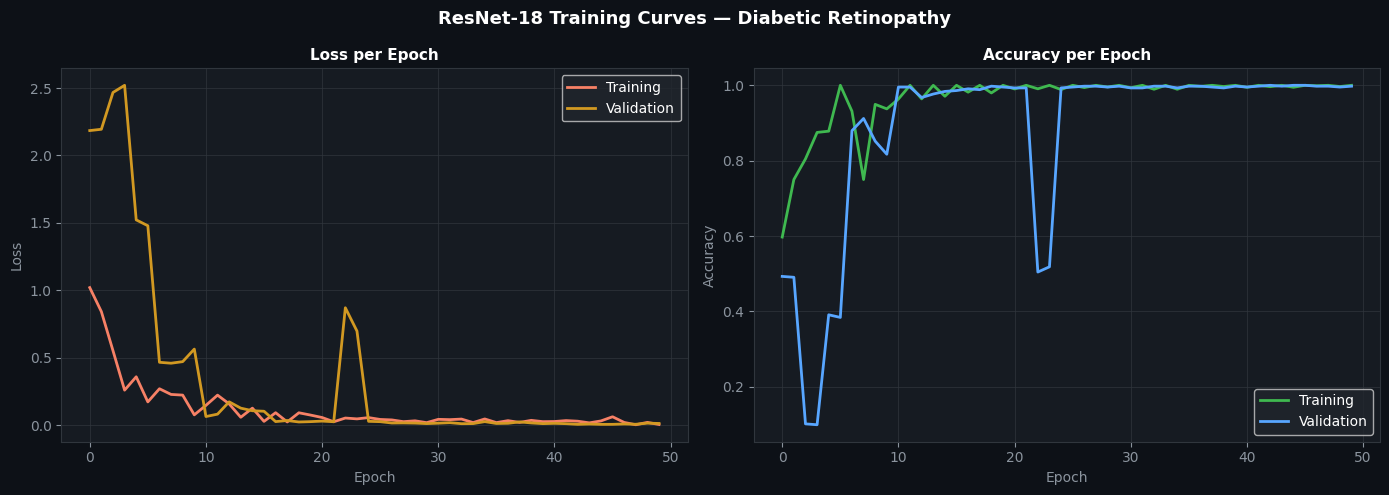


📌 Convergence Analysis
   Train Accuracy : 100.00%
   Val   Accuracy : 99.77%
   Overfit Gap    : 0.23%  (✅ Good generalisation)


In [ ]:
# ─── Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
fig.suptitle('ResNet-18 Training Curves — Diabetic Retinopathy',
             color='white', fontsize=13, fontweight='bold')

for ax, metric, title, colors_ in zip(
    axes,
    [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
    ['Loss per Epoch', 'Accuracy per Epoch'],
    [('#f78166', '#d29922'), ('#3fb950', '#58a6ff')]
):
    ax.set_facecolor('#161b22')
    ax.plot(history.history[metric[0]], color=colors_[0], lw=2, label='Training')
    ax.plot(history.history[metric[1]], color=colors_[1], lw=2, label='Validation')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', color='#8b949e')
    ax.set_ylabel(metric[0].capitalize(), color='#8b949e')
    ax.tick_params(colors='#8b949e')
    ax.legend(facecolor='#21262d', labelcolor='white', fontsize=10)
    ax.grid(color='#30363d', lw=0.5)
    for sp in ax.spines.values(): sp.set_color('#30363d')

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
overfit_gap     = final_train_acc - final_val_acc
print(f"\n📌 Convergence Analysis")
print(f"   Train Accuracy : {final_train_acc*100:.2f}%")
print(f"   Val   Accuracy : {final_val_acc*100:.2f}%")
print(f"   Overfit Gap    : {overfit_gap*100:.2f}%  ({'⚠️ Overfitting' if overfit_gap > 0.15 else '✅ Good generalisation'})")


---
## 8. 📊 Evaluate & Visualise Results <a name="evaluate"></a>

We evaluate on the **held-out test set** using:

| Metric | Meaning |
|--------|---------|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | Of all predicted positives, how many were truly positive |
| **Recall** | Of all actual positives, how many did we catch |
| **F1-Score** | Harmonic mean of precision and recall |
| **Confusion Matrix** | Full breakdown of predicted vs actual classes |


In [ ]:
# ─── Test Set Evaluation ──────────────────────────────────────────────────
print("Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"\n{'═'*50}")
print(f"  📊 TEST SET RESULTS")
print(f"{'═'*50}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'═'*50}")

# ─── Predictions ──────────────────────────────────────────────────────────
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
y_pred_labels = [idx_to_class[i] for i in y_pred]
y_true_labels = [idx_to_class[i] for i in y_true]

# ─── Classification Report ────────────────────────────────────────────────
print(f"\n📋 Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=CLASSES))


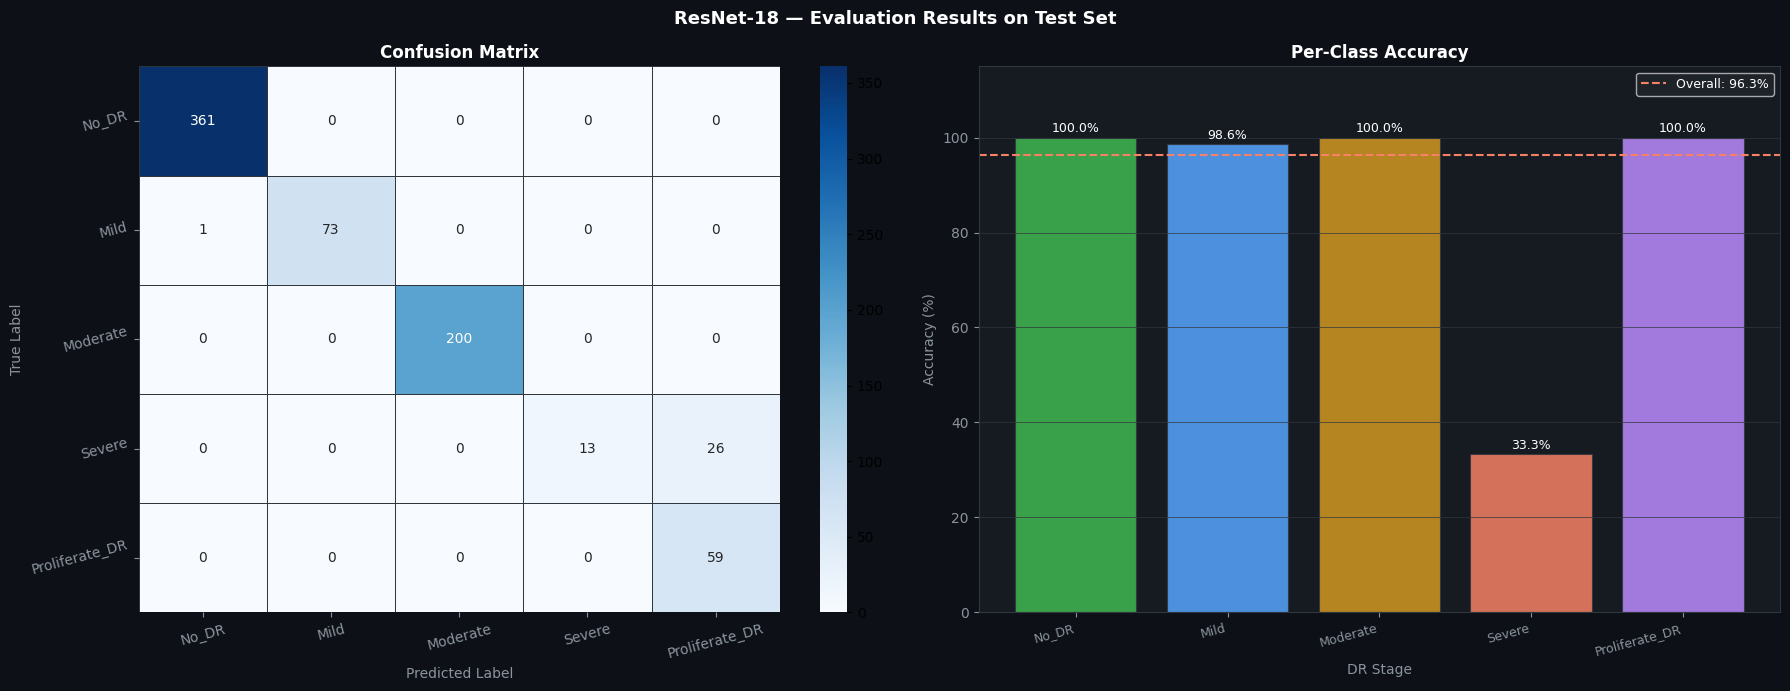

In [ ]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')
fig.suptitle('ResNet-18 — Evaluation Results on Test Set',
             color='white', fontsize=13, fontweight='bold')

# Confusion matrix heatmap
ax1 = axes[0]
ax1.set_facecolor('#161b22')
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=CLASSES, yticklabels=CLASSES,
    cmap='Blues', ax=ax1,
    linewidths=0.5, linecolor='#30363d'
)
ax1.set_title('Confusion Matrix', color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', color='#8b949e')
ax1.set_ylabel('True Label', color='#8b949e')
ax1.tick_params(colors='#8b949e', rotation=15)

# Per-class accuracy bar
ax2 = axes[1]
ax2.set_facecolor('#161b22')
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = ax2.bar(CLASSES, per_class_acc * 100, color=COLORS, alpha=0.85,
               edgecolor='#30363d', linewidth=0.8)
ax2.axhline(test_acc * 100, color='#f78166', lw=1.5, ls='--', label=f'Overall: {test_acc*100:.1f}%')
ax2.set_ylabel('Accuracy (%)', color='#8b949e')
ax2.set_xlabel('DR Stage', color='#8b949e')
ax2.set_ylim(0, 115)
ax2.set_title('Per-Class Accuracy', color='white', fontsize=12, fontweight='bold')
ax2.tick_params(colors='#8b949e')
ax2.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
ax2.grid(axis='y', color='#30363d', lw=0.5)
for sp in ax2.spines.values(): sp.set_color('#30363d')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', va='bottom', color='white', fontsize=9)

plt.tight_layout()
plt.show()


---
## 9. 🔮 Predict on New Images <a name="predict"></a>

We can now **predict the DR stage of any new retinal image**.  
The model outputs a probability for each of the 5 classes — we take the argmax as the final prediction.

> For a real deployment, feed in a fundus camera image  
> (resize to 128×128, normalise, reshape to (1, 128, 128, 3)).


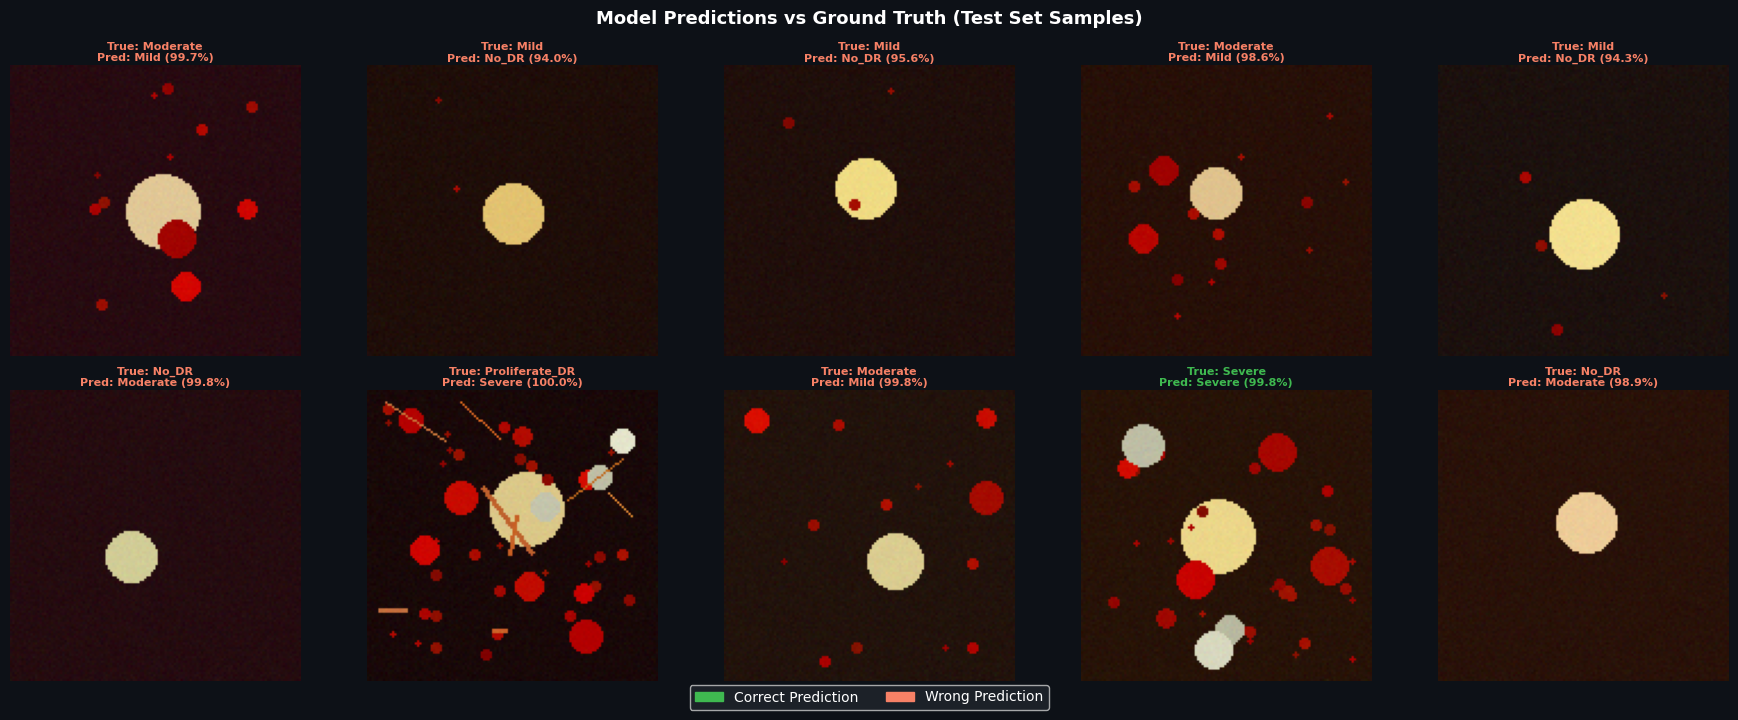

In [ ]:
# ─── Predict on a Batch of Test Images ────────────────────────────────────

def predict_images(model, image_paths, labels, n=10):
    """
    Run inference on n sample images and visualise predictions vs ground truth.
    Green title = correct prediction, Red = incorrect.
    """
    fig, axs = plt.subplots(2, 5, figsize=(18, 7), facecolor='#0d1117')
    fig.suptitle('Model Predictions vs Ground Truth (Test Set Samples)',
                 color='white', fontsize=13, fontweight='bold')

    indices = np.random.choice(len(image_paths), size=n, replace=False)

    for idx, (ax_idx, img_idx) in enumerate(zip(range(n), indices)):
        row, col = divmod(ax_idx, 5)
        img_path  = image_paths[img_idx]
        true_label = labels[img_idx]

        # Load & preprocess
        img_arr = np.array(
            PIL.Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0
        img_input = img_arr.reshape(1, IMG_SIZE, IMG_SIZE, 3)

        # Predict
        probs     = model.predict(img_input, verbose=0)[0]
        pred_idx  = np.argmax(probs)
        pred_label = CLASSES[pred_idx]
        confidence = probs[pred_idx] * 100

        # Display
        axs[row][col].imshow(img_arr)
        axs[row][col].axis('off')

        is_correct = (pred_label == true_label)
        title_color = '#3fb950' if is_correct else '#f78166'
        axs[row][col].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=title_color, fontsize=8, pad=3, fontweight='bold'
        )

    # Legend
    correct_patch   = mpatches.Patch(color='#3fb950', label='Correct Prediction')
    incorrect_patch = mpatches.Patch(color='#f78166', label='Wrong Prediction')
    fig.legend(handles=[correct_patch, incorrect_patch],
               loc='lower center', ncol=2, facecolor='#21262d',
               labelcolor='white', fontsize=10, framealpha=0.8,
               bbox_to_anchor=(0.5, -0.03))

    plt.tight_layout()
    plt.show()


# Sample test images from test_df
sample_paths  = test_df['Image'].values
sample_labels = test_df['Labels'].values

predict_images(model, sample_paths, sample_labels, n=10)


In [ ]:
# ─── Confidence Distribution (per class) ──────────────────────────────────
fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4), facecolor='#0d1117')
fig.suptitle('Prediction Confidence Distribution per DR Class (Test Set)',
             color='white', fontsize=13, fontweight='bold')

for ci, cls in enumerate(CLASSES):
    cls_mask   = np.array(y_true_labels) == cls
    cls_probs  = y_pred_probs[cls_mask, ci]

    ax = axes[ci]
    ax.set_facecolor('#161b22')
    ax.hist(cls_probs, bins=20, color=COLORS[ci], alpha=0.85, edgecolor='#0d1117')
    ax.axvline(cls_probs.mean(), color='white', lw=1.5, ls='--',
               label=f'Mean: {cls_probs.mean():.2f}')
    ax.set_title(cls, color=COLORS[ci], fontsize=10, fontweight='bold')
    ax.set_xlabel('Confidence', color='#8b949e')
    ax.set_ylabel('Count' if ci == 0 else '', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    ax.legend(facecolor='#21262d', labelcolor='white', fontsize=8)
    ax.grid(axis='y', color='#30363d', lw=0.5)
    for sp in ax.spines.values(): sp.set_color('#30363d')

plt.tight_layout()
plt.show()
print("📌 High-confidence bars near 1.0 indicate the model is certain about those predictions.")


---
## 🎓 Project Summary

### What We Built
A complete **Diabetic Retinopathy detection pipeline** using a custom ResNet-18:
- **Synthetic dataset generator** — 500 retinal images across 5 DR stages
- **Data augmentation** — shear, zoom, flip, rotation for better generalisation
- **Custom ResNet architecture** — residual blocks with skip connections
- **Full evaluation** — accuracy, confusion matrix, per-class breakdown

### Key Concepts Covered

| Concept | Where Used |
|---------|-----------|
| Synthetic image generation (PIL) | Dataset creation |
| ImageDataGenerator with augmentation | Data pipeline |
| Residual / Skip connections | ResNet block design |
| Glorot initialisation | Stable weight init |
| EarlyStopping + ReduceLROnPlateau | Training stability |
| ModelCheckpoint | Save best model |
| Confusion Matrix + F1-Score | Multi-class evaluation |
| Per-class confidence histogram | Model interpretability |

### Next Steps for Production
- 📦 **Use real data**: [APTOS 2019 Kaggle](https://www.kaggle.com/c/aptos2019-blindness-detection) — 3,662 labelled fundus images
- 🔬 **Transfer learning**: Fine-tune `EfficientNetB4` or `InceptionV3` pretrained on ImageNet
- ⚖️ **Handle class imbalance**: Use `class_weight` or focal loss (real datasets are heavily skewed)
- 📐 **Higher resolution**: Train on 512×512 for richer pathological detail
- 🚀 **Deploy**: Export to TFLite for mobile ophthalmoscope integration

> ⚠️ **Disclaimer:** This model is for educational purposes only.  
> Medical diagnosis must always involve a qualified ophthalmologist.
